In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df=pd.read_csv(r"C:\Users\Kirti\OneDrive\Desktop\Loan Default Prediction\data\processed\cleaned_loan_data.csv")

In [3]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,male,married,master's,24240.19,2020.02,employed,0.074,743,17173.72,...,36,581.88,b5,7,40833.47,24302.07,1,0,1,1
1,72,female,married,bachelor's,20172.98,1681.08,employed,0.219,531,22663.89,...,60,573.17,f1,5,27968.01,10803.01,1,0,3,1
2,49,female,single,high school,26181.80,2181.82,employed,0.234,779,3631.36,...,60,76.32,b4,2,15502.25,4505.44,0,0,0,1
3,35,female,single,high school,11873.84,989.49,employed,0.264,809,14939.23,...,36,468.07,a5,7,18157.79,5525.63,4,0,5,1
4,63,other,single,other,25326.44,2110.54,employed,0.260,663,16551.71,...,60,395.50,d5,1,17467.56,3593.91,2,0,2,1


In [4]:
df.shape

(20000, 22)

In [5]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [6]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [7]:
df['loan_status_label']=df['loan_paid_back'].map({0:'Default',1:'Paid'})

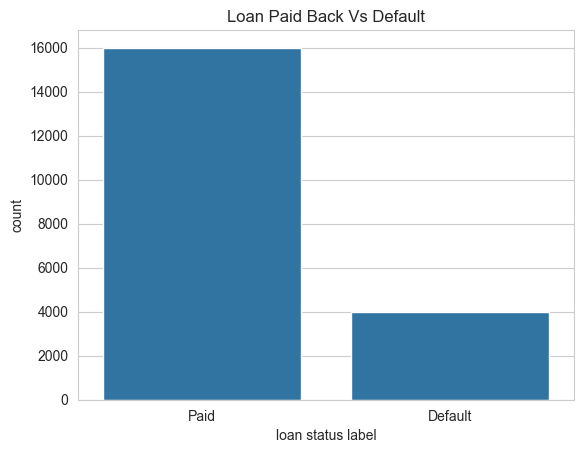

In [8]:
sns.countplot(x="loan_status_label",data=df)
plt.xlabel("loan status label")
plt.title("Loan Paid Back Vs Default")
plt.show()

In [9]:
df['loan_status_label'].value_counts(normalize=True)*100

loan_status_label
Paid       79.99
Default    20.01
Name: proportion, dtype: float64

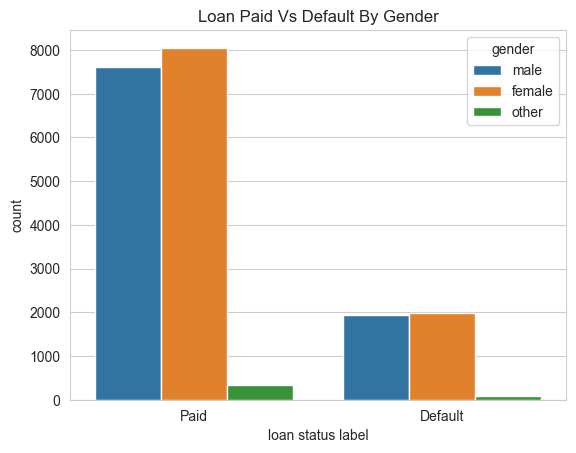

In [14]:
sns.countplot(x='loan_status_label',data=df,hue='gender')
plt.title("Loan Paid Vs Default By Gender")
plt.xlabel("loan status label")
plt.show()

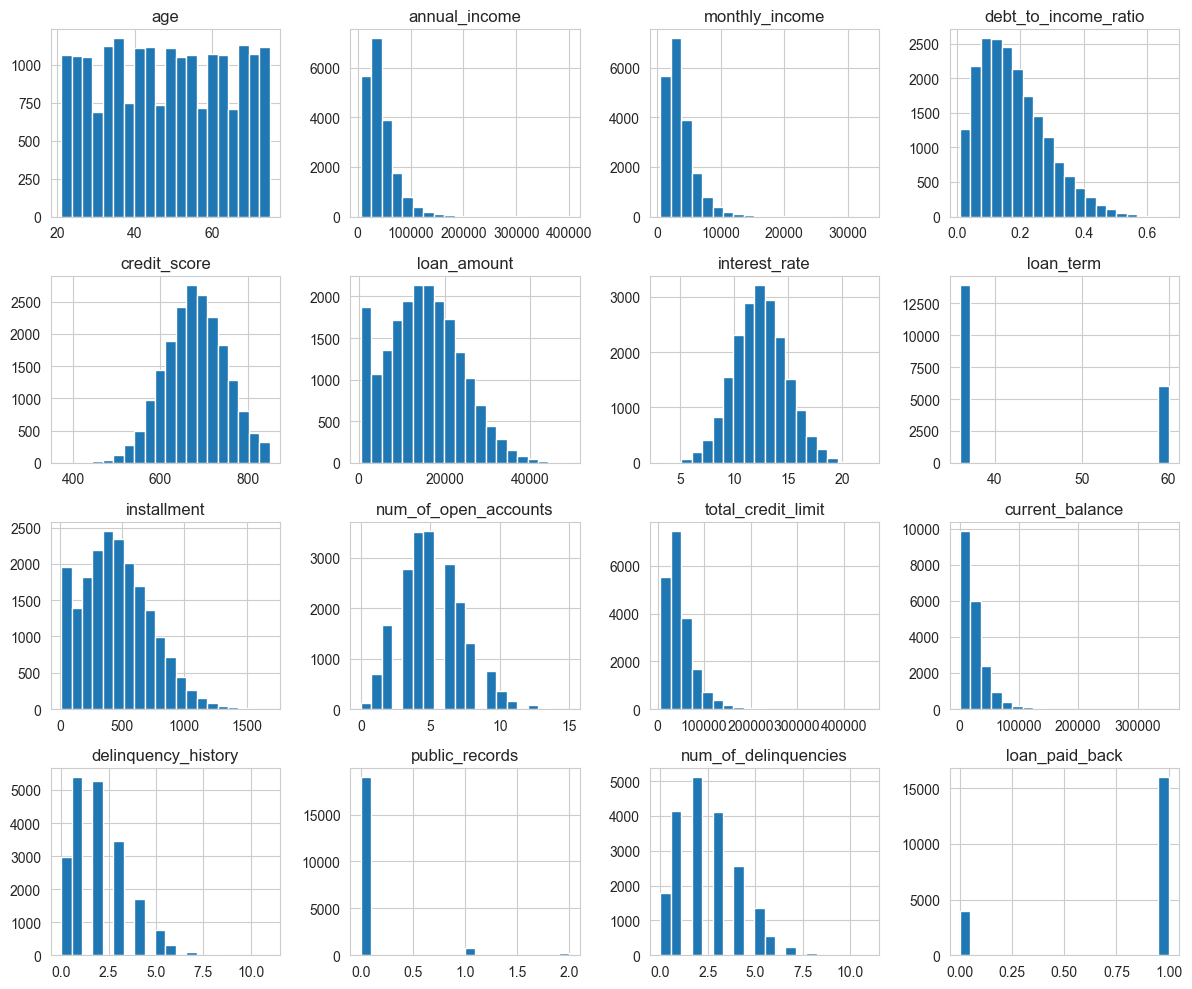

In [15]:
num_cols=df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()

Loan Amount By Age

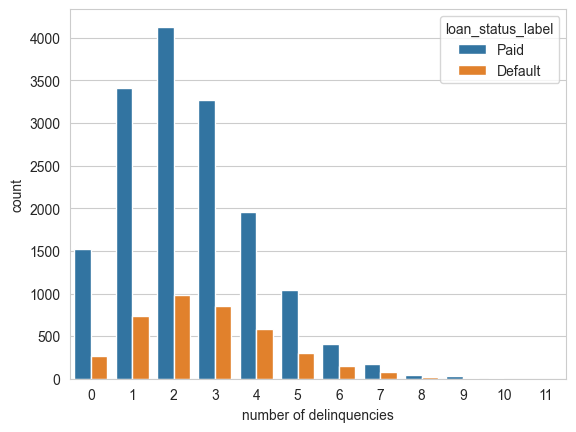

In [26]:
sns.countplot(data=df,x='num_of_delinquencies',hue='loan_status_label')
plt.xlabel("number of delinquencies")
plt.show()

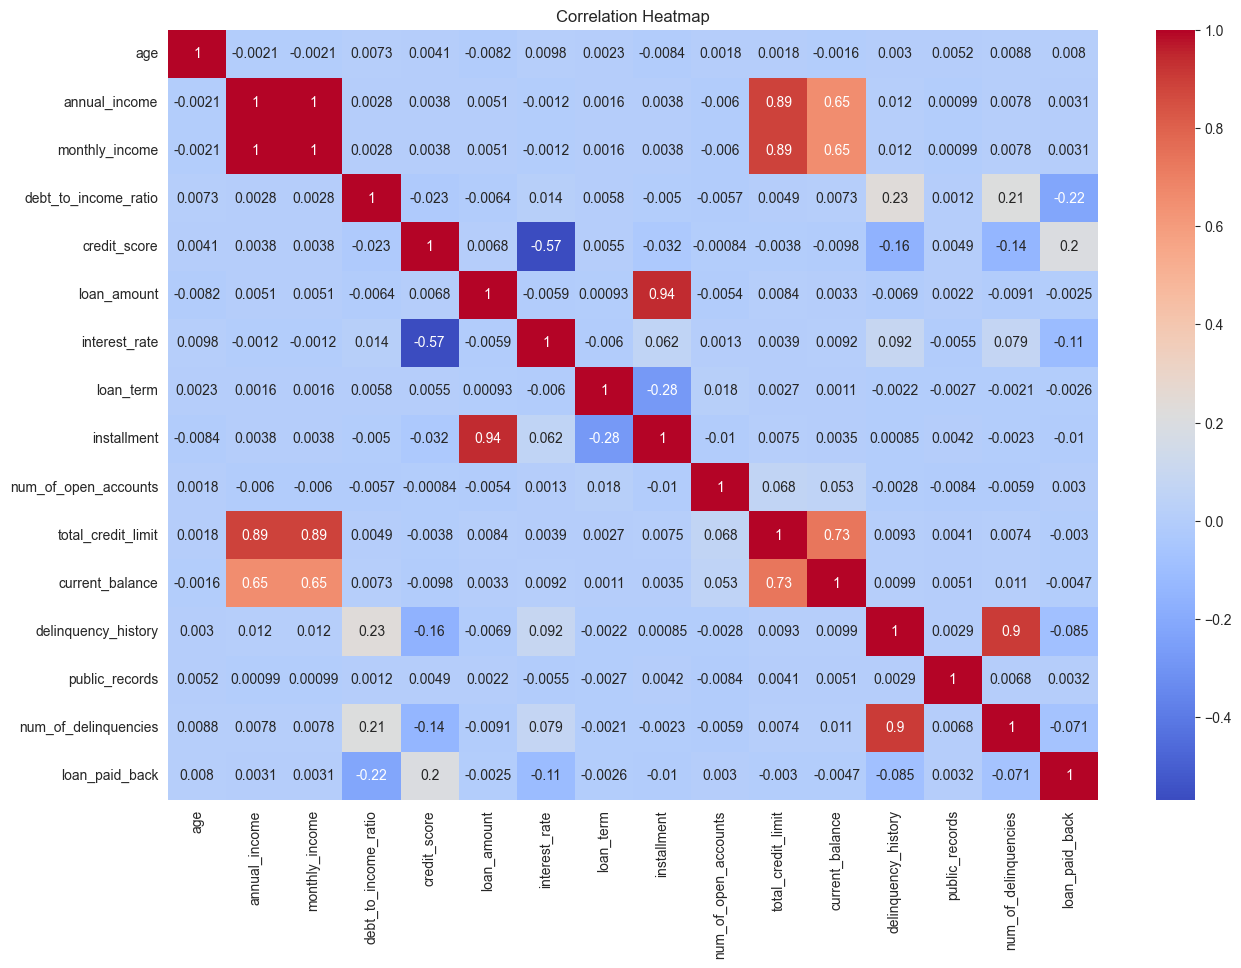

In [21]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Numerical Feature Analysis

In [40]:
num_cols=df.select_dtypes(include=np.number).columns
num_cols

Index(['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'interest_rate', 'loan_term',
       'installment', 'num_of_open_accounts', 'total_credit_limit',
       'current_balance', 'delinquency_history', 'public_records',
       'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

<Figure size 1000x500 with 0 Axes>

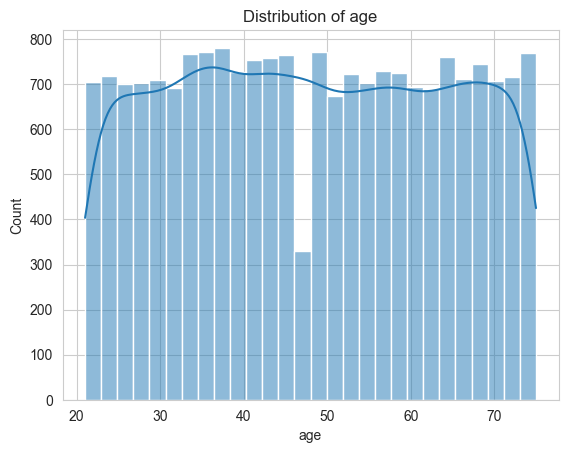

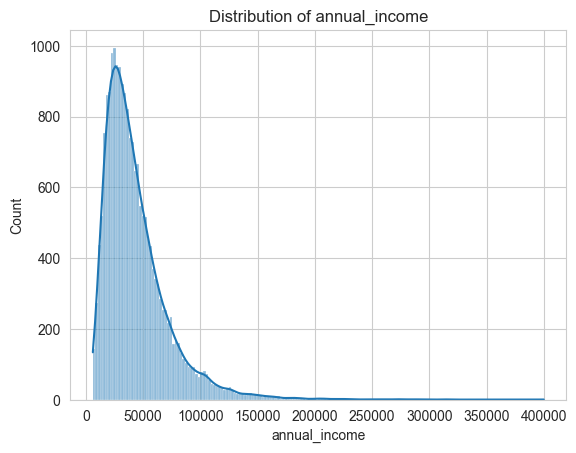

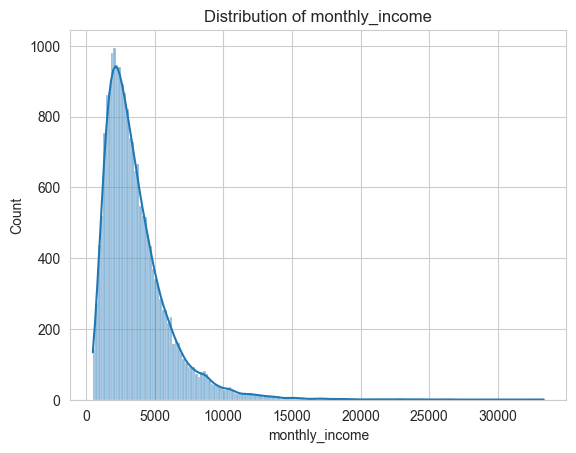

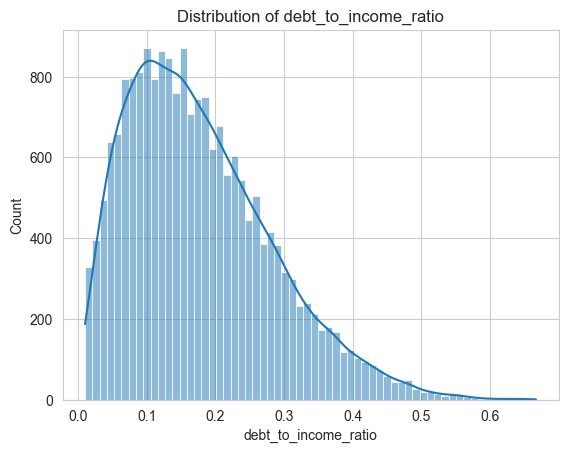

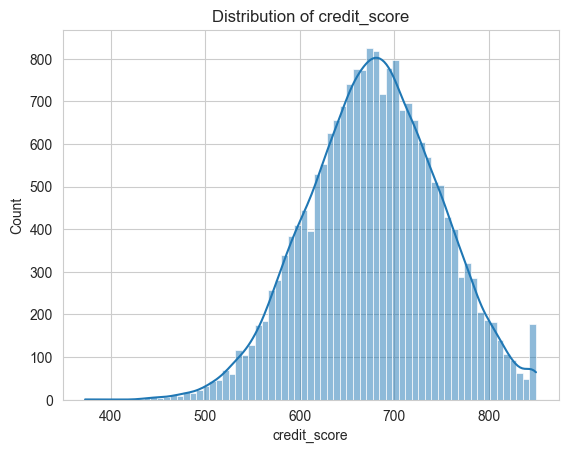

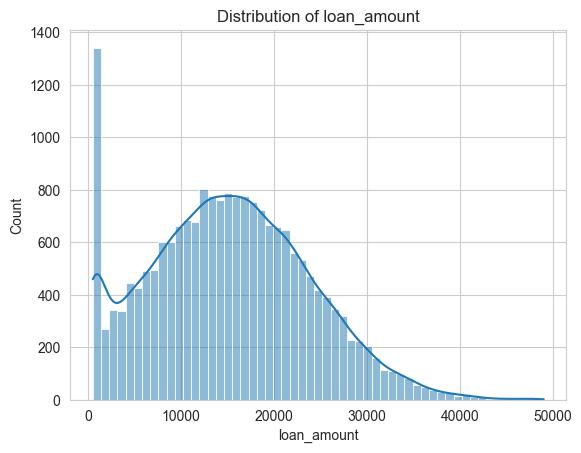

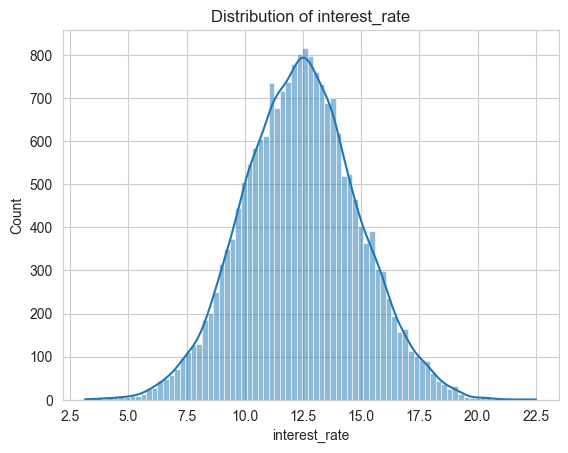

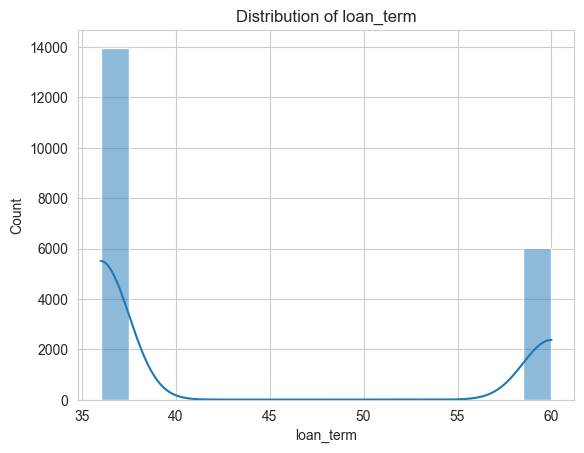

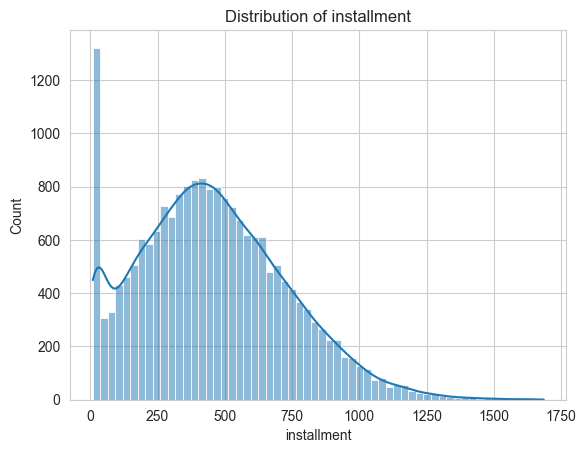

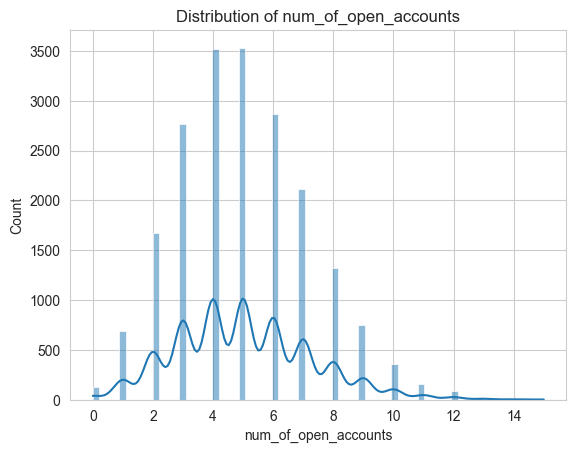

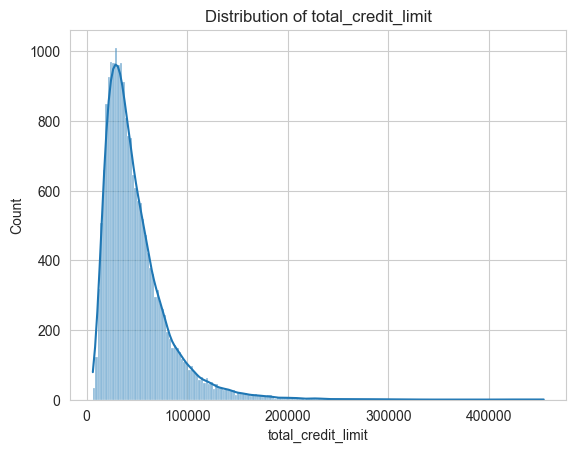

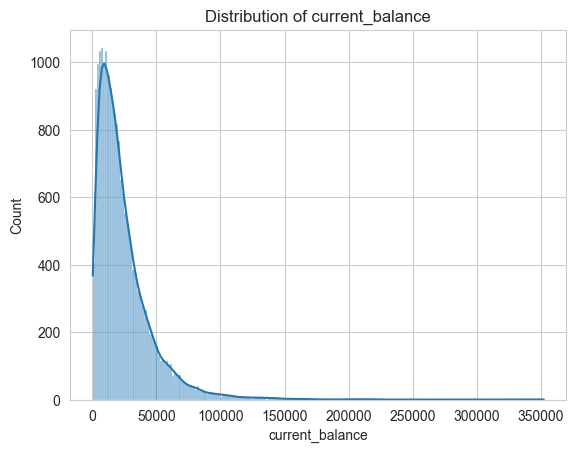

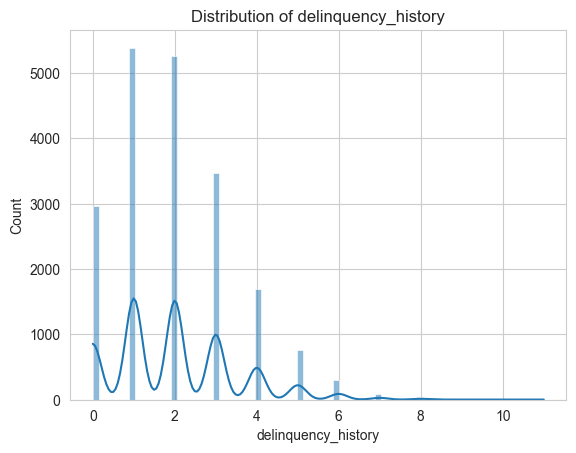

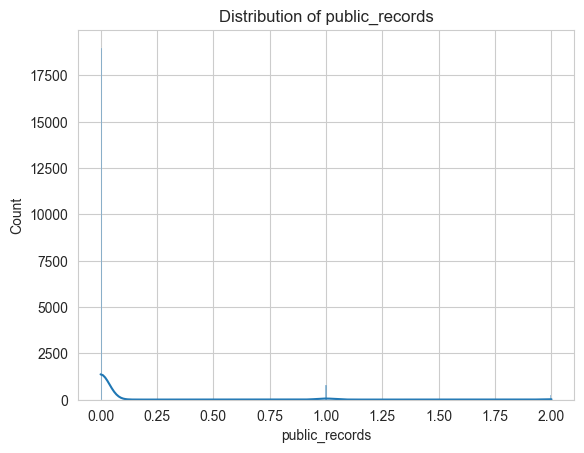

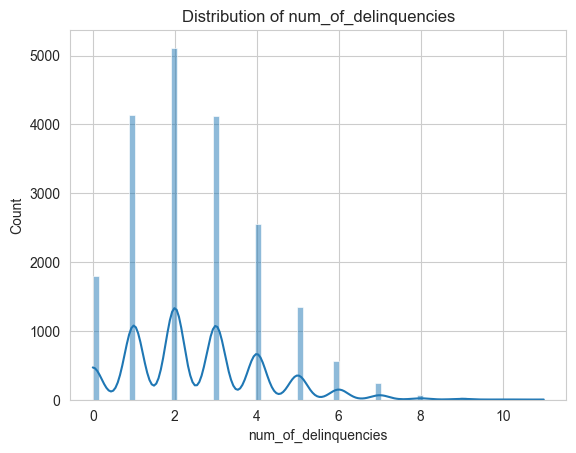

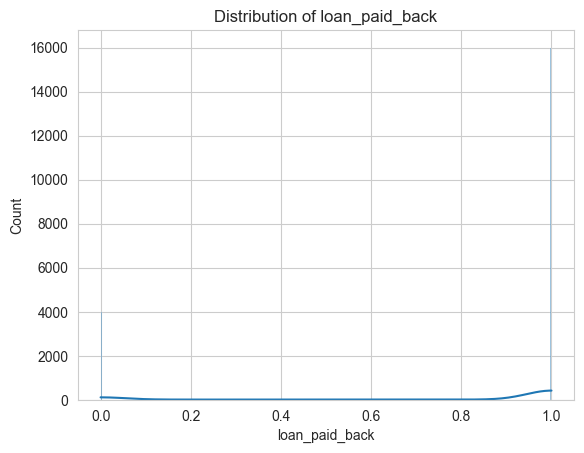

In [41]:
plt.figure(figsize=(10,5))
for col in num_cols:
    plt.figure() 
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Categorical Feature Analysis

In [37]:
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade', 'loan_status_label'],
      dtype='object')

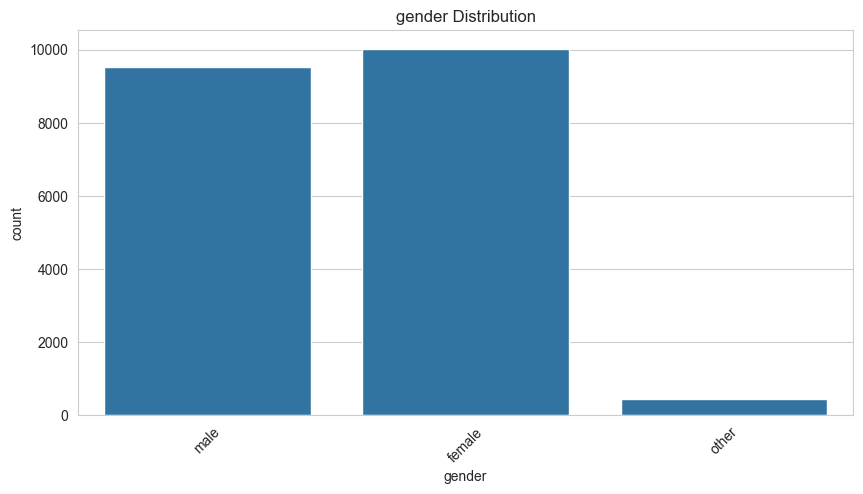

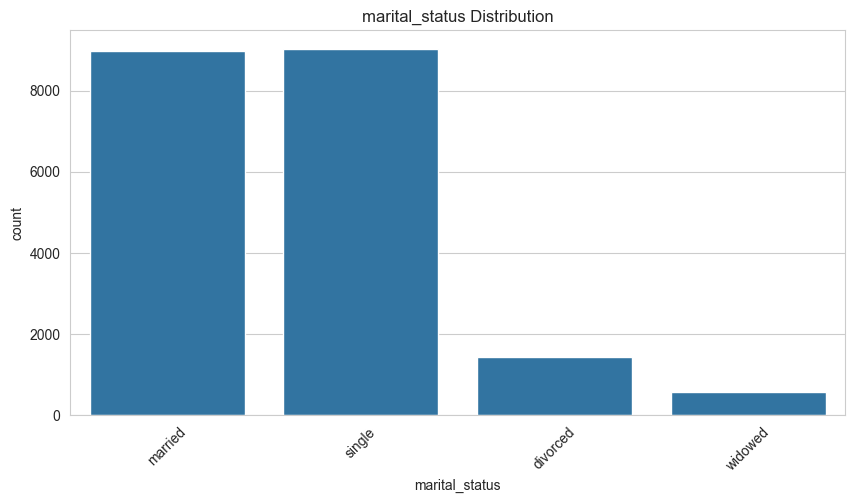

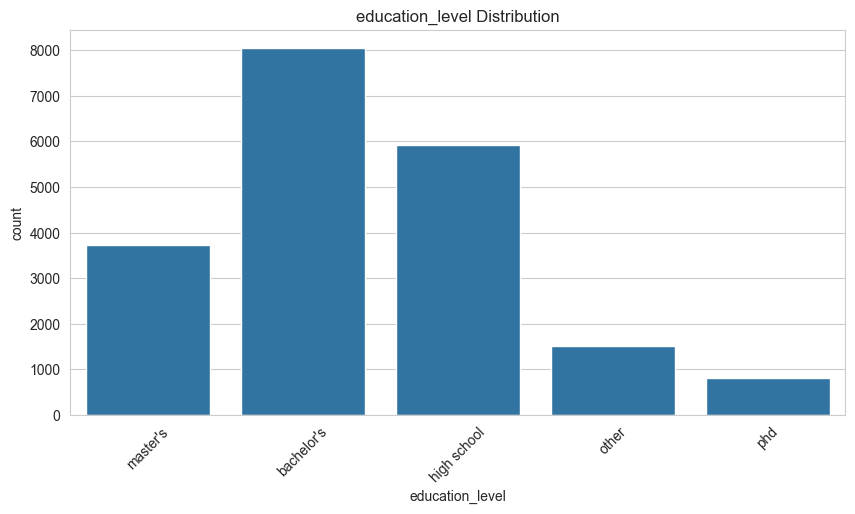

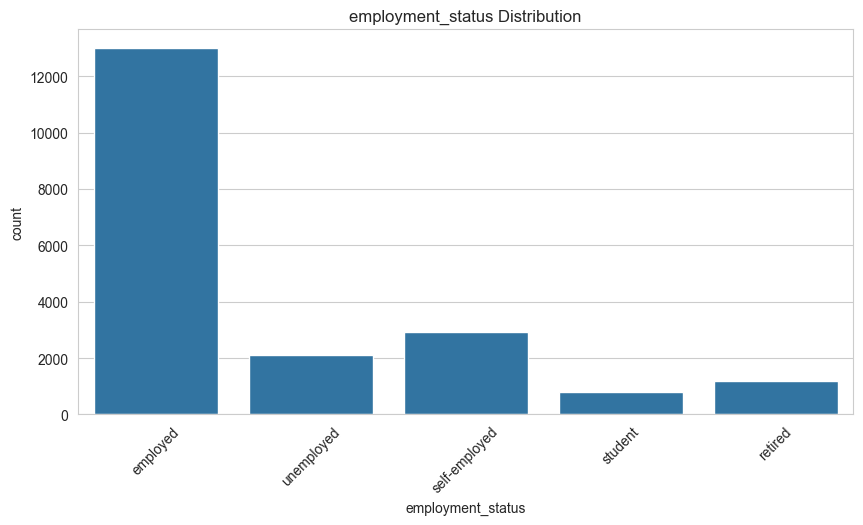

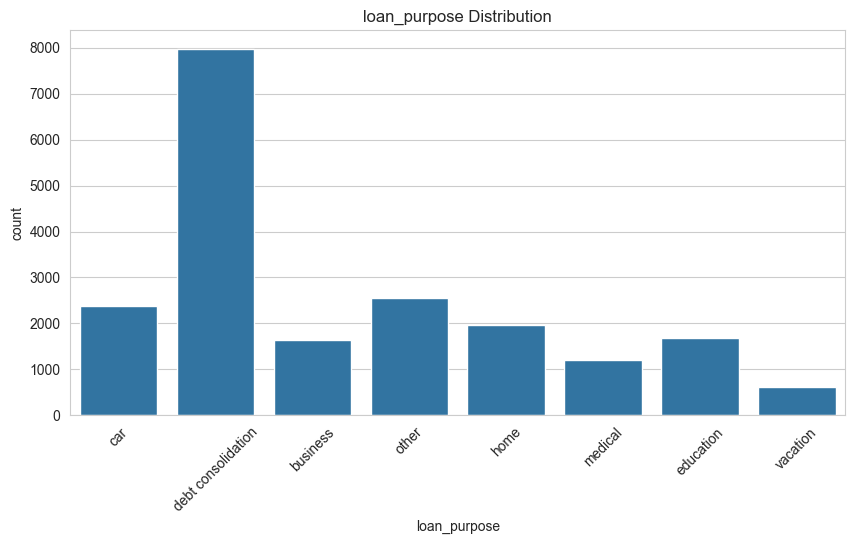

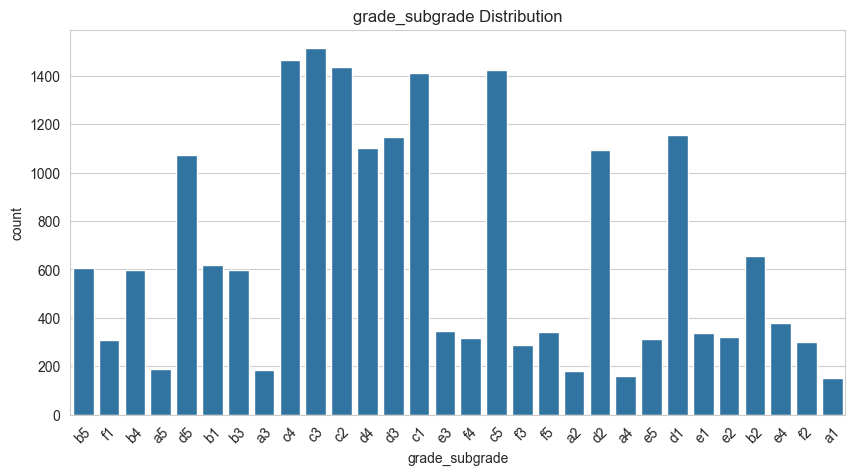

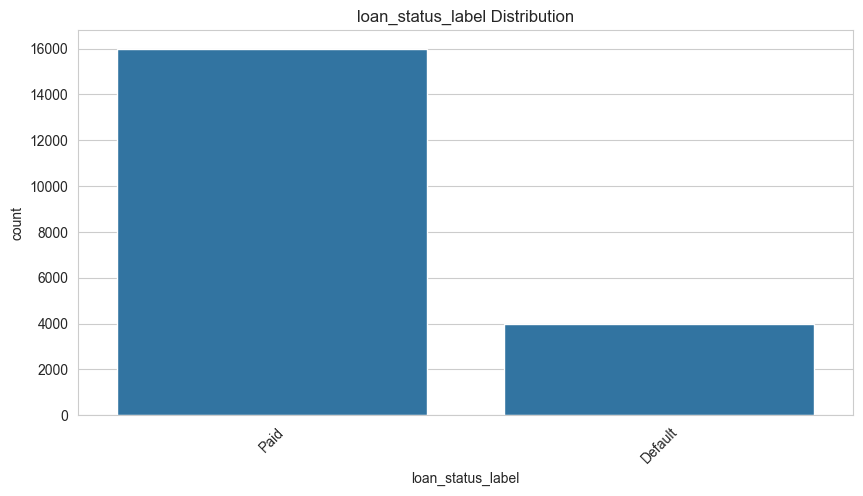

In [39]:
for col in cat_cols: 
    plt.figure(figsize=(10,5))
    sns.countplot(x=col,data=df)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()
    

Numerical Vs Target

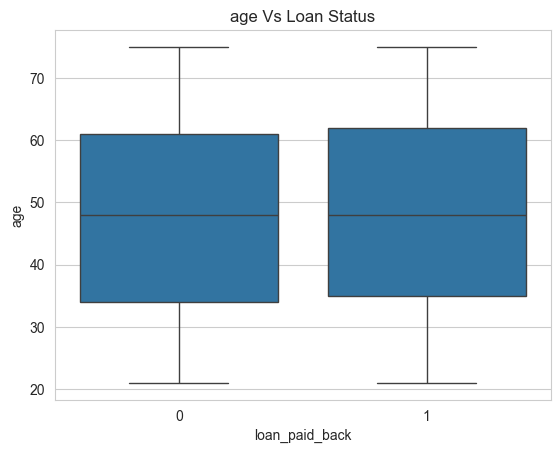

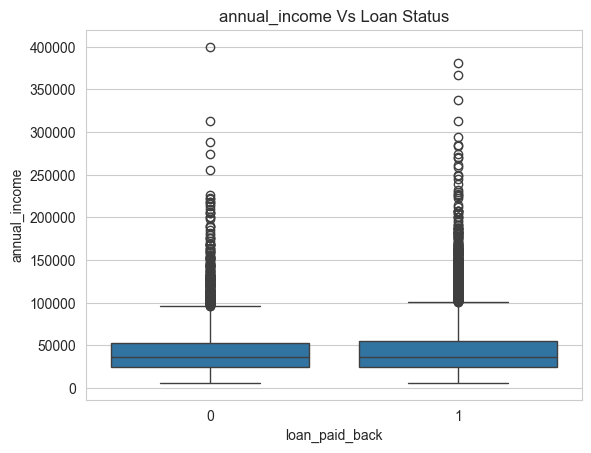

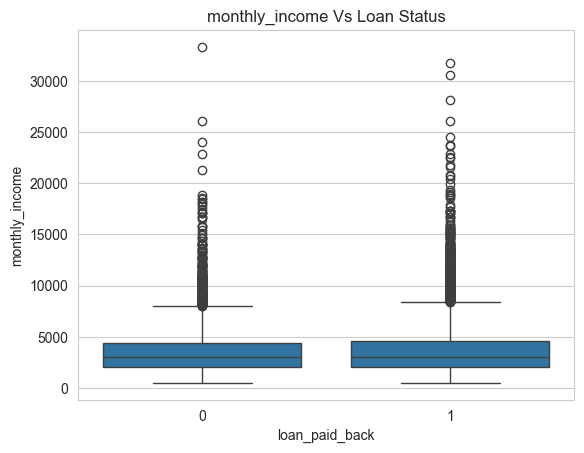

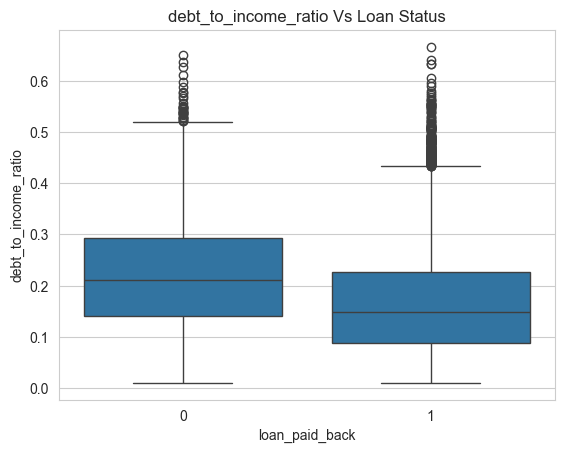

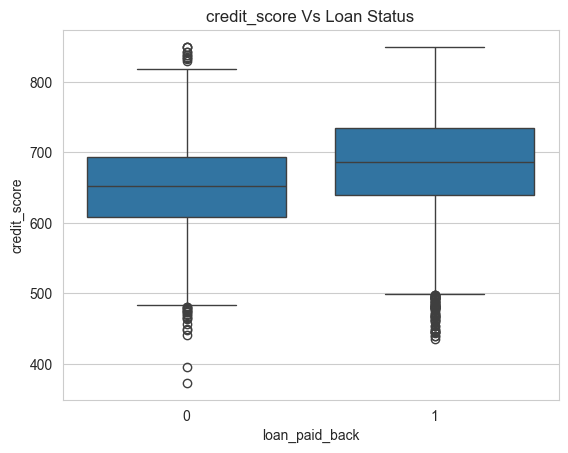

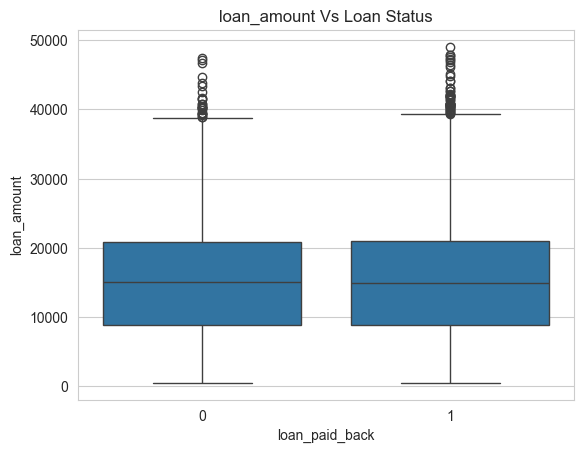

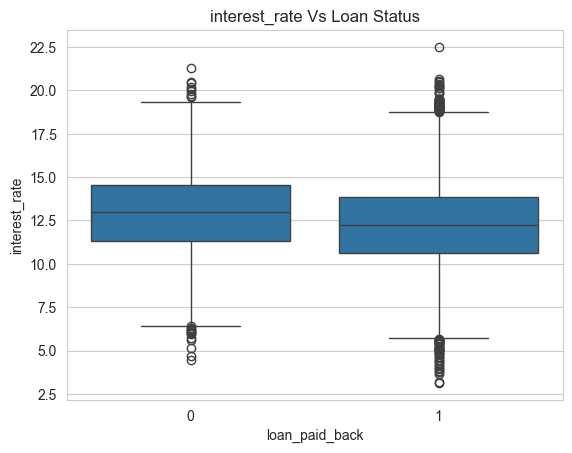

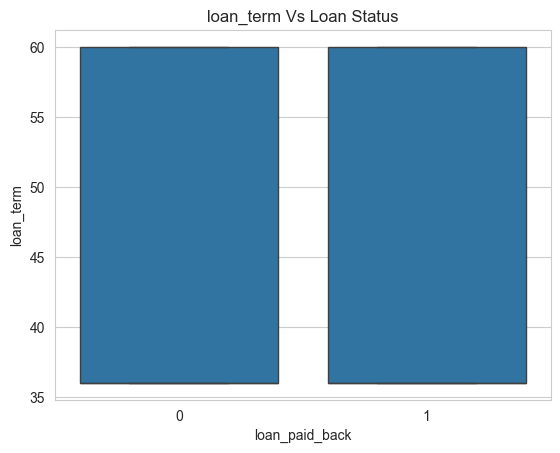

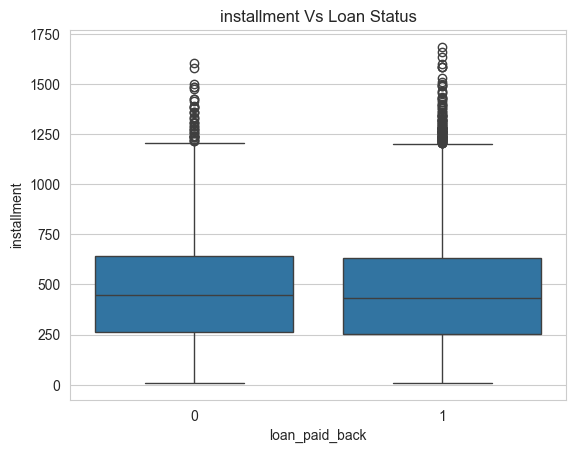

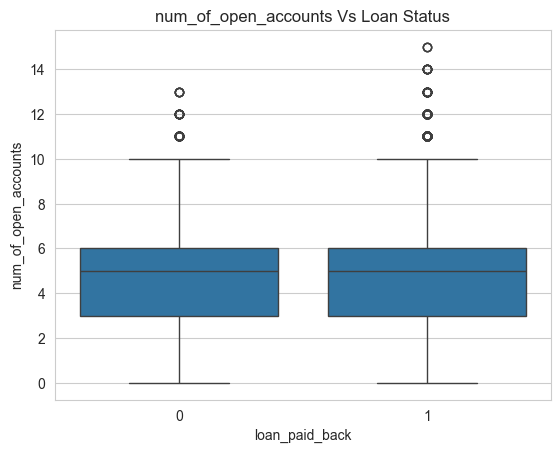

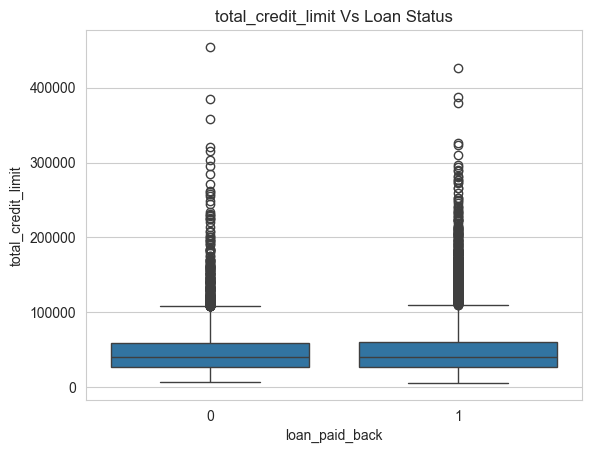

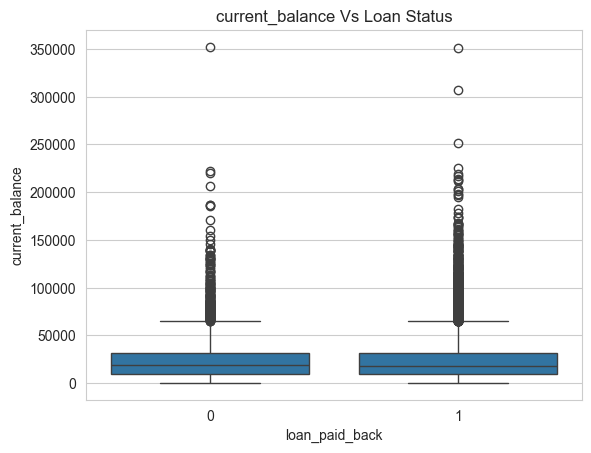

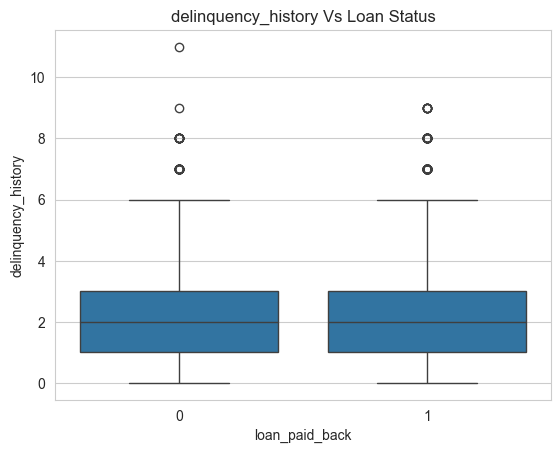

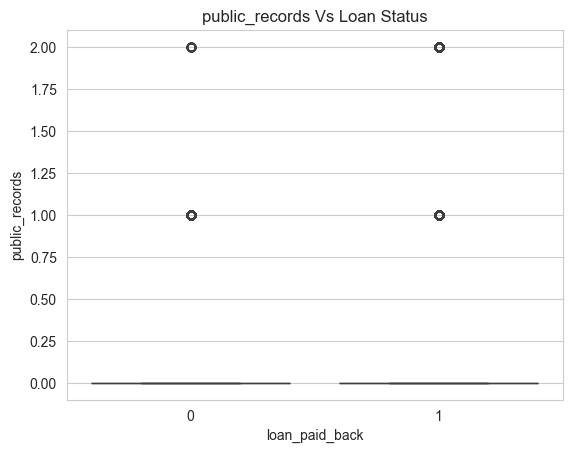

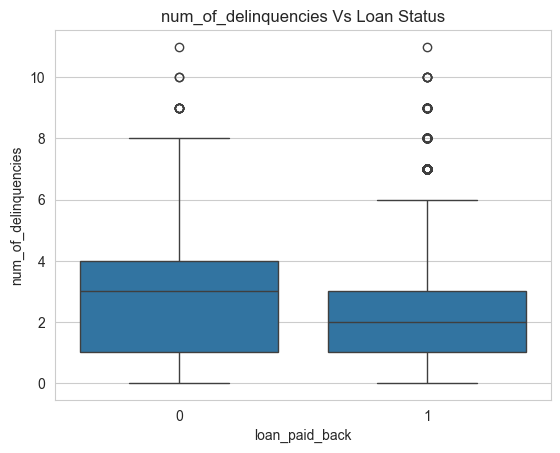

In [44]:
for col in num_cols: 
    if col!='loan_paid_back':
        plt.figure()
        sns.boxplot(x='loan_paid_back',y=col,data=df)
        plt.title(f"{col} Vs Loan Status")
        plt.show()

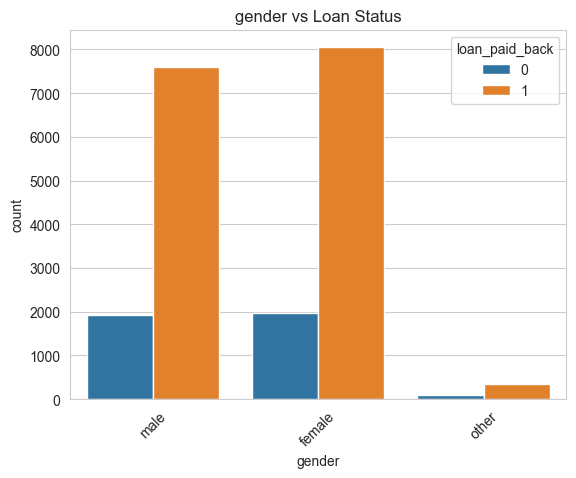

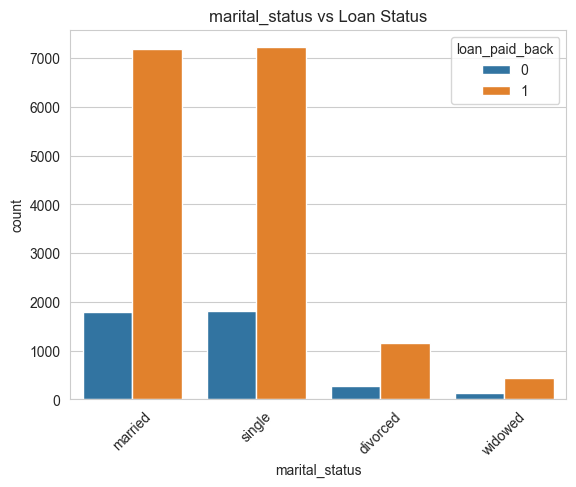

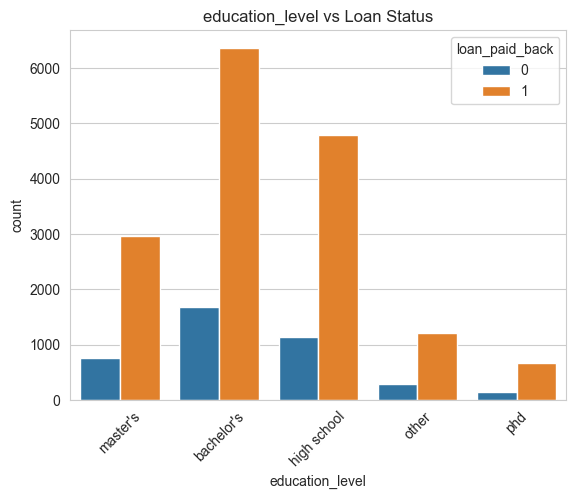

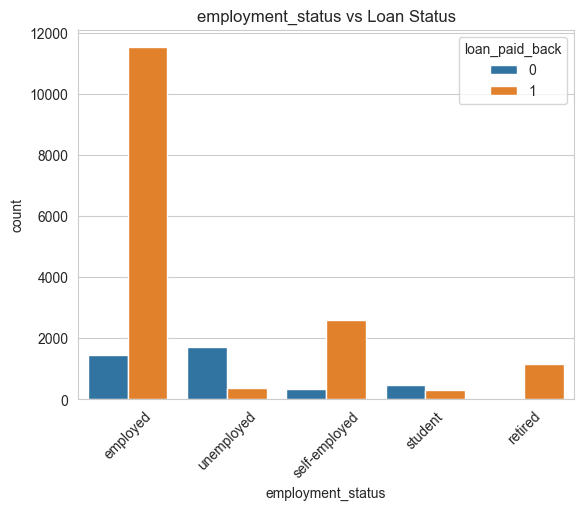

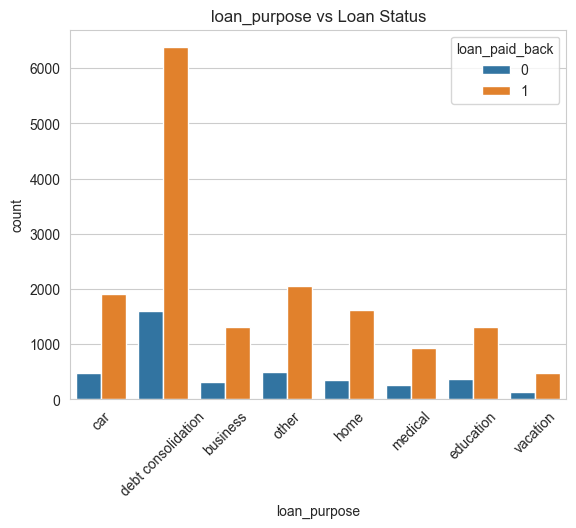

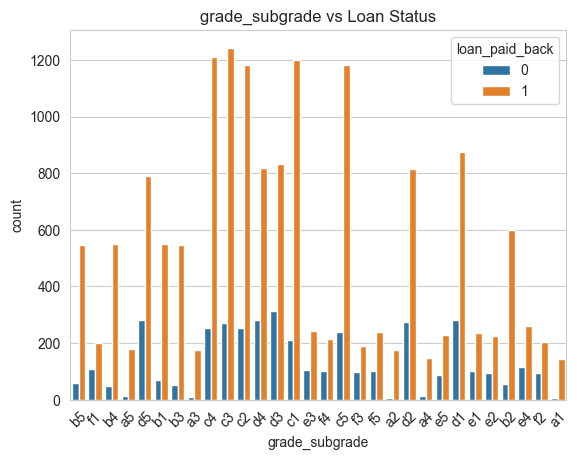

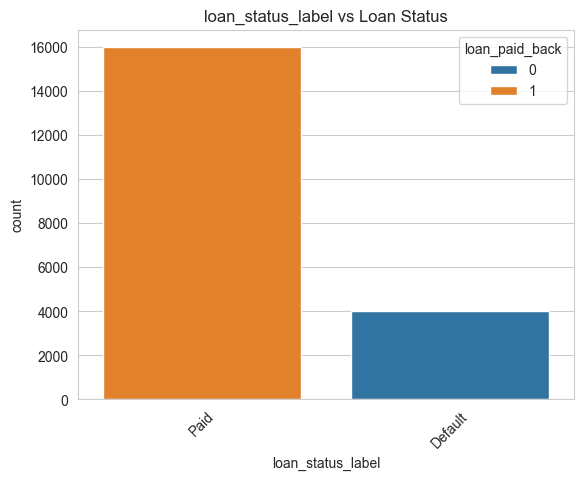

In [45]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col,hue='loan_paid_back',data=df)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

Outlier Detection

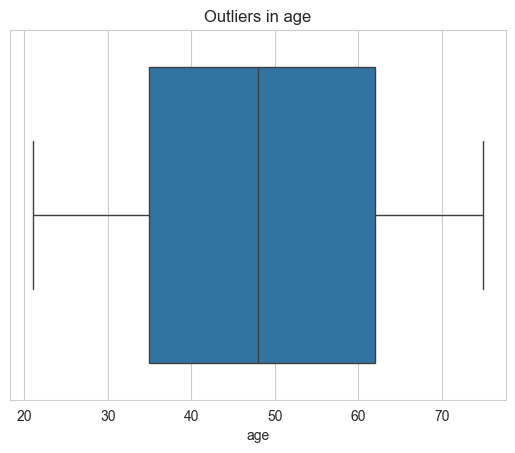

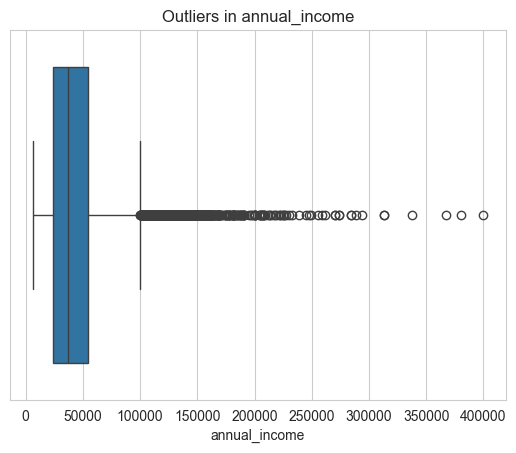

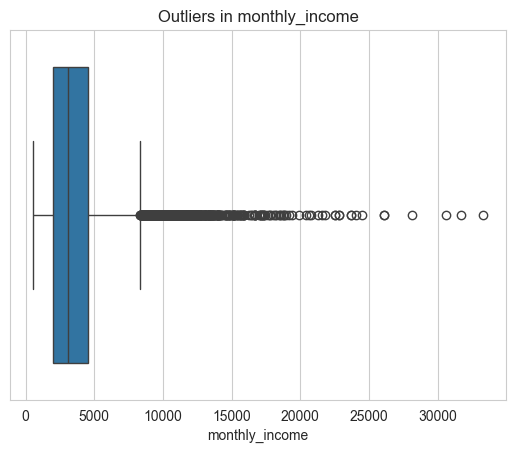

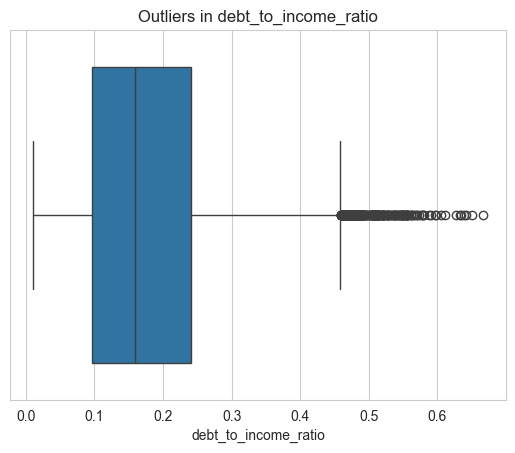

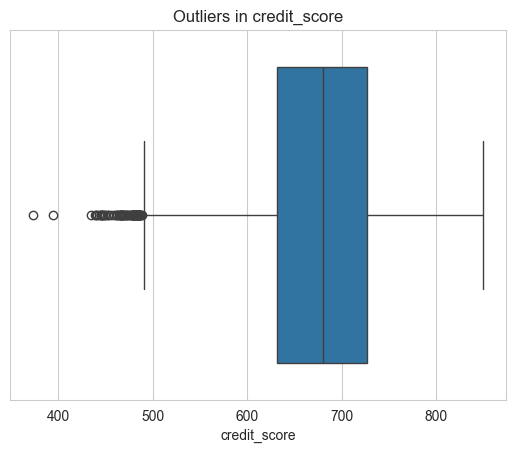

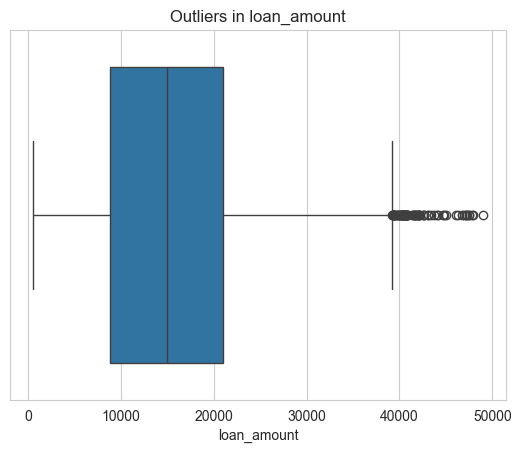

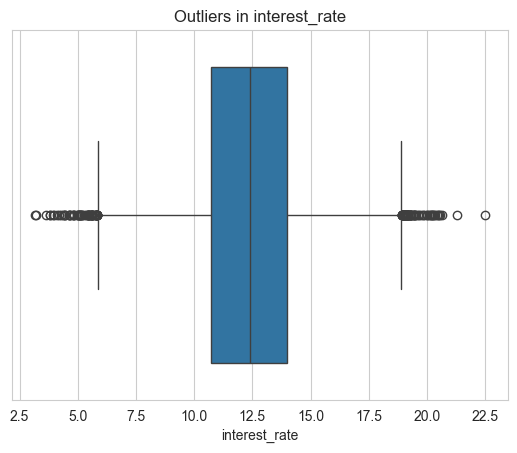

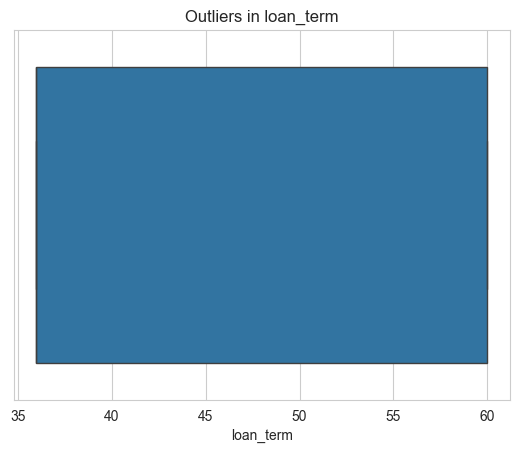

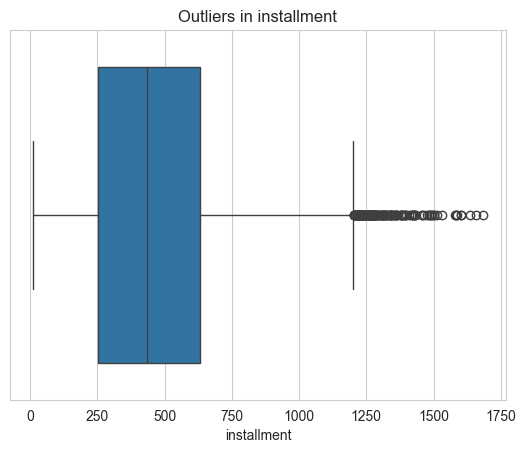

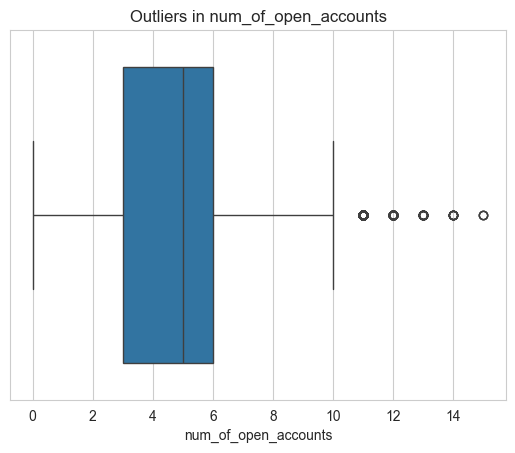

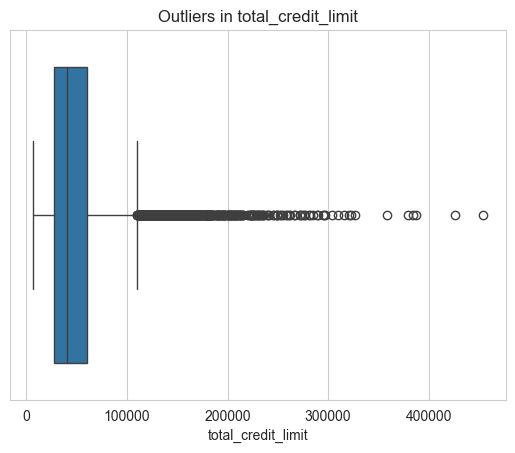

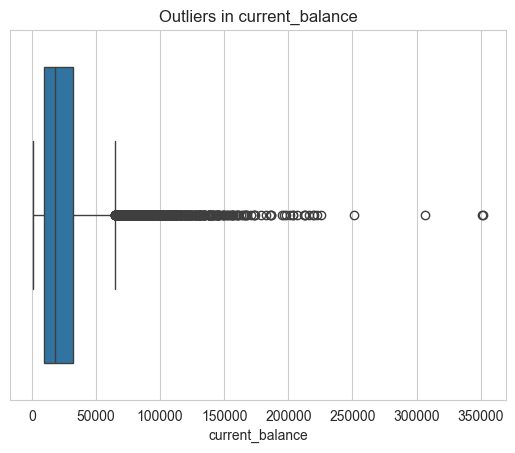

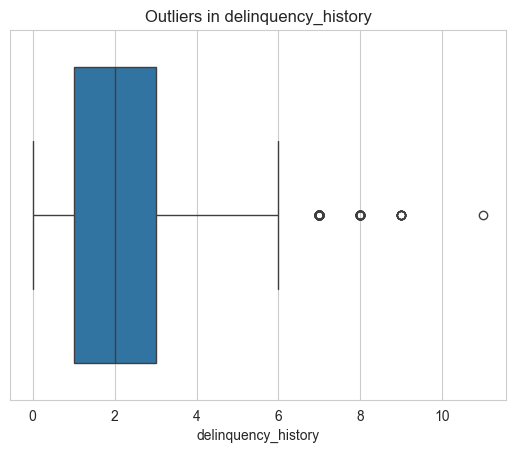

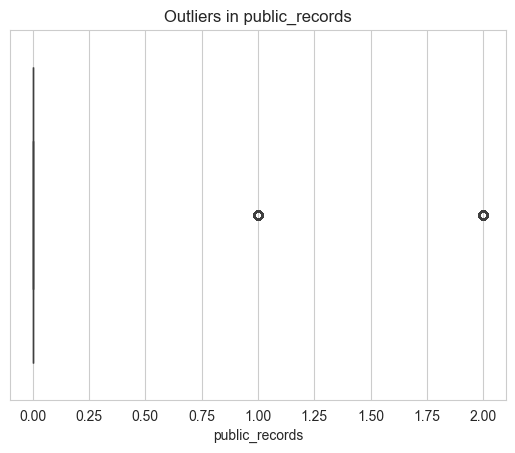

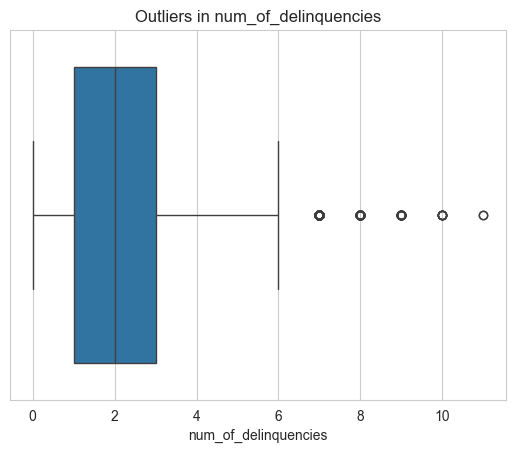

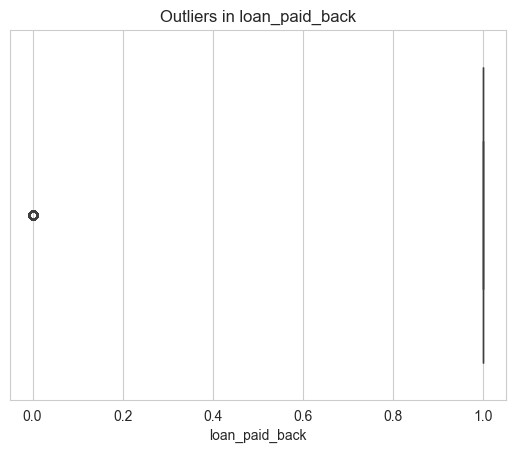

In [47]:
for col in num_cols: 
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()